Notebook to generate consistent harmonic and real space data vectors.

In [23]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from copy import deepcopy
import os
import time
import astropy.io.fits as fits
from scipy import interpolate

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.summary_statistics.angular_correlation_function_wigner import AngularCorrelationFunctionWigner
from cloelib.auxiliary.cosebi_helpers import get_W_ell

import euclidlib as el
import heracles # used to save cls to fits files

import seaborn as sns
sns.set_theme(style='ticks')
sns.set_palette(sns.color_palette("Paired"))

In [24]:
# Plot settings
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.subplot.left'] = 0.125
plt.rcParams['figure.subplot.right'] = 0.9
plt.rcParams['figure.subplot.bottom'] = 0.125
plt.rcParams['figure.subplot.top'] = 0.9
plt.rcParams['axes.labelsize'] = 28
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.labelsize'] = 17
plt.rcParams['ytick.labelsize'] = 17
plt.rcParams['xtick.major.pad'] = 6.
plt.rcParams['xtick.minor.pad'] = 6.
plt.rcParams['ytick.major.pad'] = 6.
plt.rcParams['ytick.minor.pad'] = 6.
plt.rcParams['xtick.major.size'] = 6. # major tick size in points
plt.rcParams['xtick.minor.size'] = 3. # minor tick size in points
plt.rcParams['ytick.major.size'] = 6. # major tick size in points
plt.rcParams['ytick.minor.size'] = 3. # minor tick size in points
plt.rcParams['font.family'] =  'serif'
plt.rcParams['font.size'] = 2 
plt.rcParams['axes.linewidth'] = 2.0 

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"

In [25]:
# Directory path with input files: n(z), MM
path_in = '.../dv_generator/input/'

# Directory path where you want to save data
path_out = '.../dv_generator/output/'

## 1. Common quantities

### 1.1. Cosmology

In [26]:
# Cosmology
background = CAMBBackground(H0 = 67., 
                            Omega_cdm0 = 0.27, 
                            Omega_b0 = 0.049, 
                            w0 = -1, 
                            wa = 0, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2.1e-9,
                            mnu = 0.06,
                            N_mnu = 1,                          
                            gamma_MG=0
                            )

# Define redshift (z) and wavenumber (k) ranges to compute perturbations
zs = np.linspace(1e-6, 3., 500) 
kmin = 5e-4
kmax = 50
nk = 400
ks = np.logspace(np.log10(kmin), np.log10(kmax), nk)

linear_perturbations = HMemuLinearPerturbations(background, zs)
nonlinear_perturbations = HMemuNonLinearPerturbations(background, linear_perturbations, zs, log10TAGN=7.7)

# Select the perturbations you want to use
perturbations = nonlinear_perturbations

### 1.2. Redshift distributions

In [27]:
# Read with euclidlib
z_pos, nz_pos = el.photo.redshift_distributions(path_in + 'RR2_v2_Nz_GC_C2020_sel_pv.fits')
z_she, nz_she = el.photo.redshift_distributions(path_in + 'RR2_v2_Nz_WL_C2020_sel_pv.fits')

# Normalise dndz
dndz_pos_norm = deepcopy(nz_pos)
for key in nz_pos.keys():
    dndz_pos_norm[key] = nz_pos[key] / integrate.trapezoid(
                        nz_pos[key], z_pos)

dndz_she_norm = deepcopy(nz_she)
for key in nz_she.keys():
    dndz_she_norm[key] = nz_she[key] / integrate.trapezoid(
                        nz_she[key], z_she)


# Resampling the normalized n(z) with len(zs)=256 values
my_dndz_pos = np.vstack(list(dndz_pos_norm.values()))
dndz_pos = np.zeros([len(nz_pos.keys()), len(zs)])
for i in range(6):
    dndz_pos[i,:] = np.interp(zs, z_pos, my_dndz_pos[i,:])

my_dndz_she = np.vstack(list(dndz_she_norm.values()))
dndz_she = np.zeros([len(nz_she.keys()), len(zs)])
for i in range(6):
    dndz_she[i,:] = np.interp(zs, z_she, my_dndz_she[i,:])

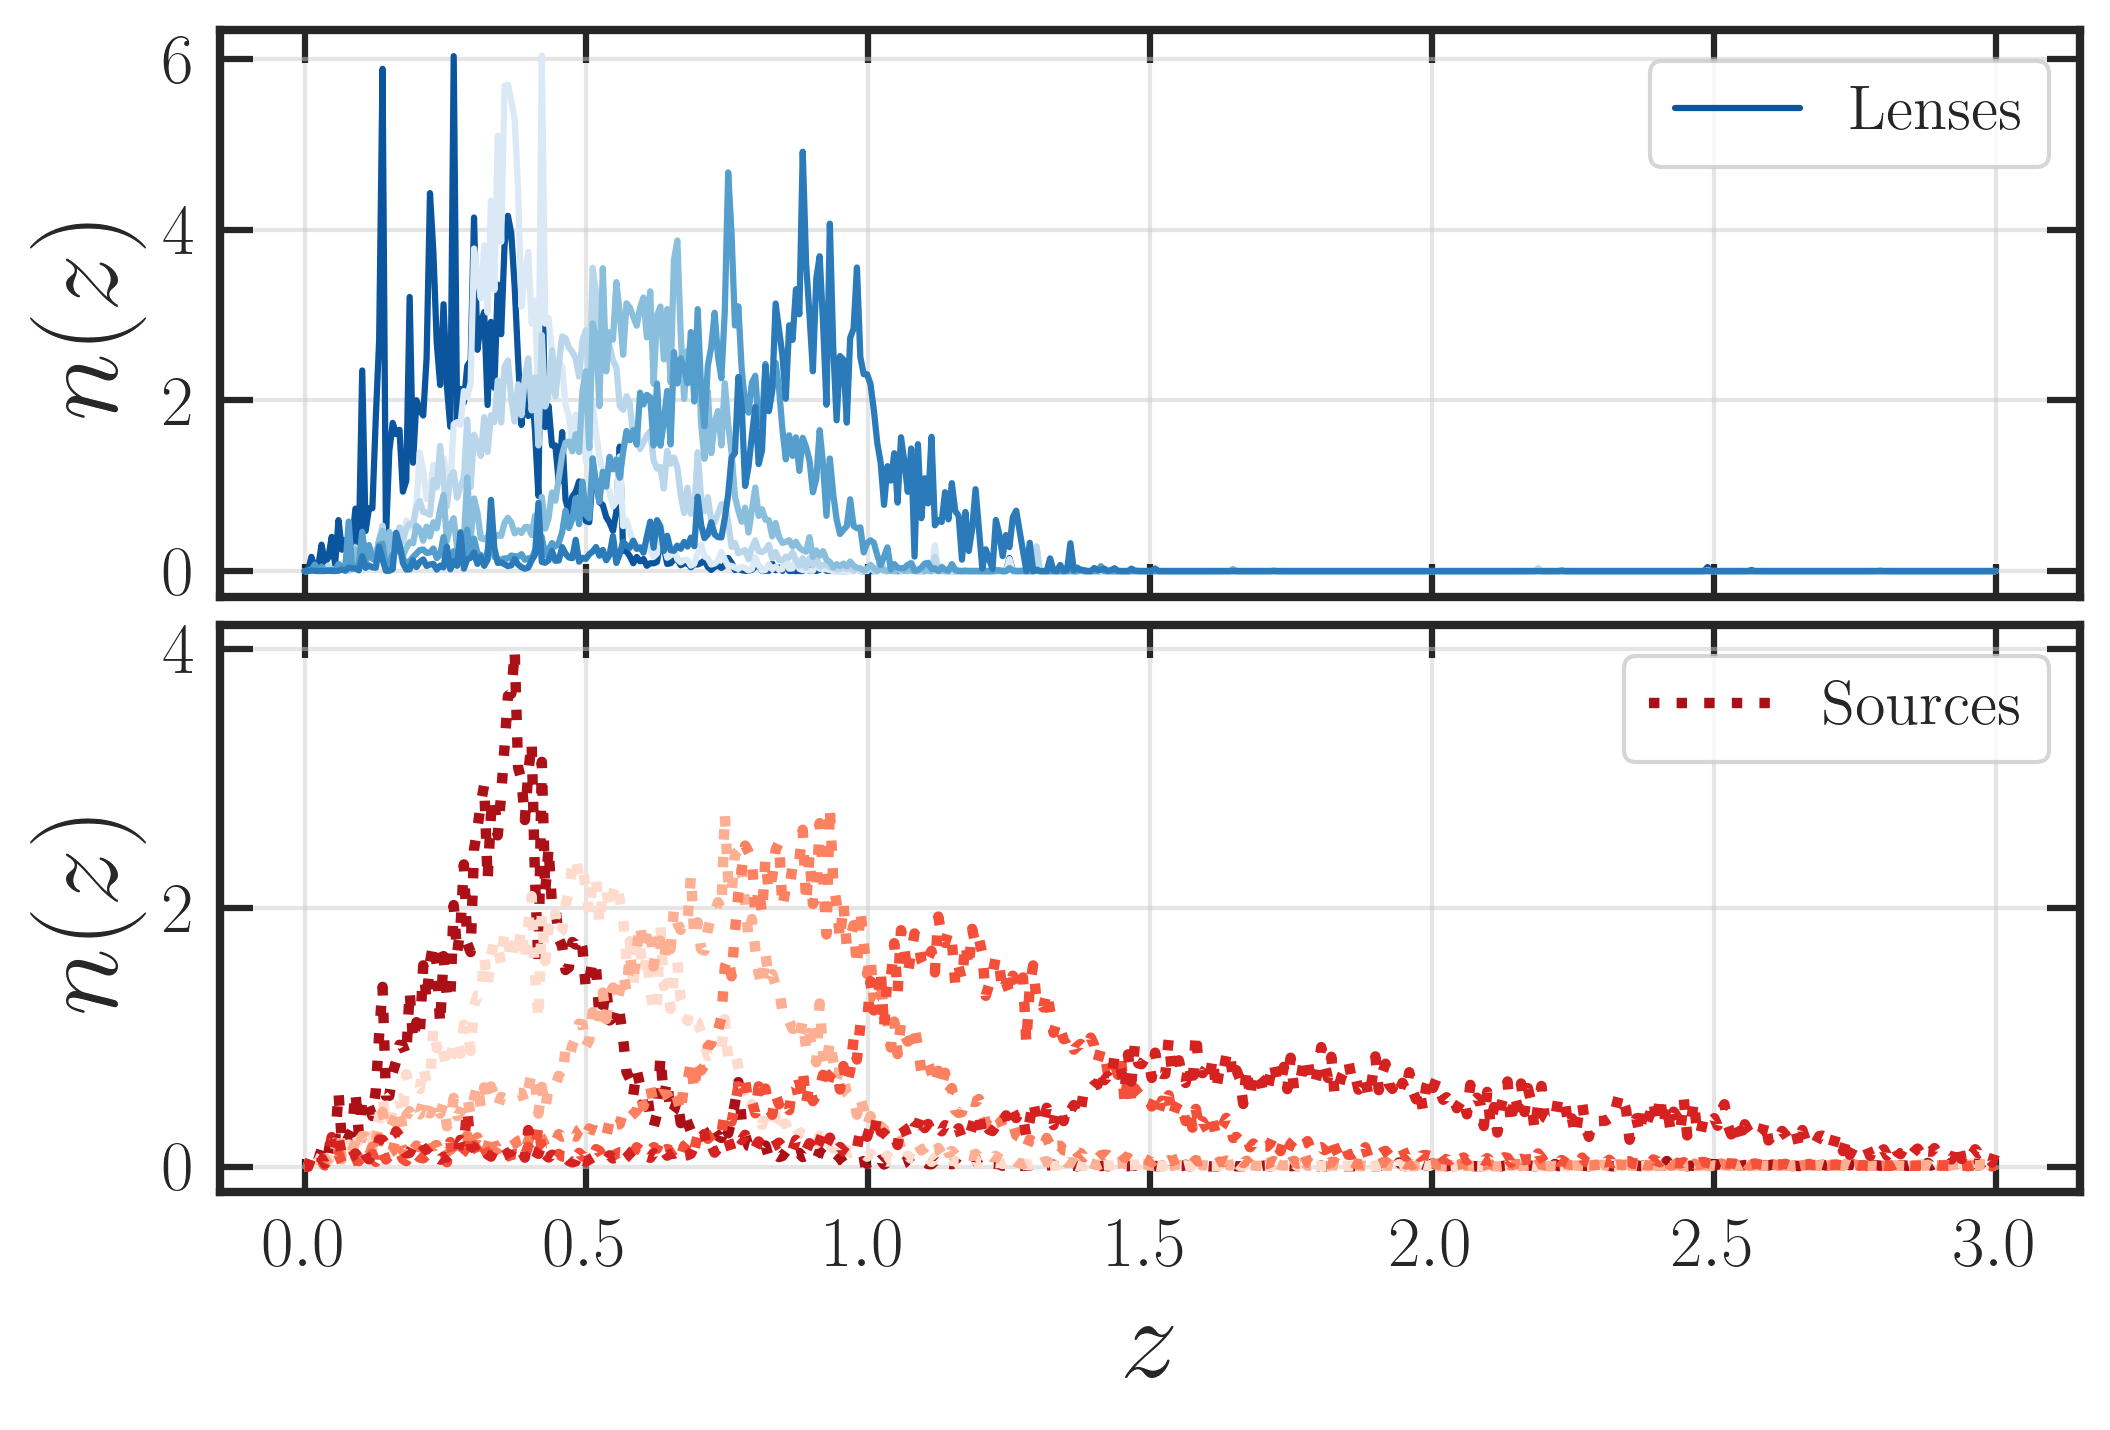

In [28]:
fig, axs = plt.subplots(2, 1, figsize=(8,5), sharex=True)
plt.subplots_adjust(wspace=0.05, hspace=0.05)

for i in range(6):
    if i==0:
        axs[0].plot(zs, dndz_pos[i,:], linewidth=1.5, color=sns.color_palette("Blues", 6)[i-1], label = r'$\rm{Lenses}$')
        axs[1].plot(zs, dndz_she[i,:], linewidth=2.5, ls=':', color=sns.color_palette("Reds", 6)[i-1], label = r'$\rm{Sources}$')

    else:
        axs[0].plot(zs, dndz_pos[i,:], linewidth=1.5, color=sns.color_palette("Blues", 6)[i-1])
        axs[1].plot(zs, dndz_she[i,:], linewidth=2.5, ls=':', color=sns.color_palette("Reds", 6)[i-1])

for i in range(2):
    axs[i].tick_params(direction='in', which='major', length=8, width=1.5, top=True, right=True)
    axs[i].tick_params(direction='in', which='minor', length=4, width=1.5, top=True, right=True)
    axs[i].grid(alpha=0.5)
    axs[i].legend(fontsize=15)
    axs[i].set_ylabel(r'$n(z)$')
    axs[i].set_xlabel(r'$z$')

### 1.3. Tracers

In [62]:
tracer_pos_cloe = PositionsTracer(perturbations=perturbations, 
                            dndz=dndz_pos,
                            z=zs,
                            galaxy_bias_model='per_bin',
                            nuisance_params={'b1_photo_bin1': 1.0, 'b1_photo_bin2': 1.0, 'b1_photo_bin3': 1.0, 'b1_photo_bin4': 1.0,
                                             'b1_photo_bin5': 1.0, 'b1_photo_bin6': 1.0, 'dz_pos_1': 0.0, 'dz_pos_2': 0.0,
                                              'dz_pos_3': 0.0, 'dz_pos_4': 0.0,
                                              'dz_pos_5': 0.0, 'dz_pos_6': 0.0,
                                              'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
                                              'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
                                              'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,}

                            )

tracer_she_cloe = ShearTracer(perturbations=perturbations, 
                            dndz=dndz_she,
                            z=zs,
                            nuisance_params={'AIA': 0.0, 'CIA': 0.0, 'EtaIA':0.0, 'multiplicative_bias_1': 0.0, 'multiplicative_bias_2': 0.0,
                                              'multiplicative_bias_3': 0.0, 'multiplicative_bias_4': 0.0,
                                              'multiplicative_bias_5': 0.0, 'multiplicative_bias_6': 0.0,
                                              'dz_shear_1': 0.0, 'dz_shear_2': 0.0,
                                              'dz_shear_3': 0.0, 'dz_shear_4': 0.0,
                                              'dz_shear_5': 0.0, 'dz_shear_6': 0.0}
                              )  

twopoint_sheshe = AngularTwoPoint(tracer_she_cloe, tracer_she_cloe)
twopoint_pospos = AngularTwoPoint(tracer_pos_cloe, tracer_pos_cloe)
twopoint_posshe = AngularTwoPoint(tracer_she_cloe, tracer_pos_cloe)

## 2. Harmonic Space Angular Spectra

### 2.1. Decoupled C'ells

In [63]:
nl = 32
ell_min = 10
ell_max = 3000
ells = np.logspace(np.log10(ell_min), np.log10(ell_max), nl)

cells = {**twopoint_sheshe.get_Cl(ells, nl, ks),
         **twopoint_pospos.get_Cl(ells, nl, ks),
         **twopoint_posshe.get_Cl(ells, nl, ks)}

### 2.2. Coupled C'ells

In [64]:
# Read mixing matrices
mm = el.photo.mixing_matrices(path_in + 'MM.fits')

nl = 100 # not used but need to pass (!)
ells_mm = mm[('SHE', 'SHE', 1, 1)].ell
pseudo_cells = {**twopoint_sheshe.get_pseudo_Cl(nl, ks, mm),
                **twopoint_pospos.get_pseudo_Cl(nl, ks, mm),
                **twopoint_posshe.get_pseudo_Cl(nl, ks, mm)}

### 2.3. Plot results

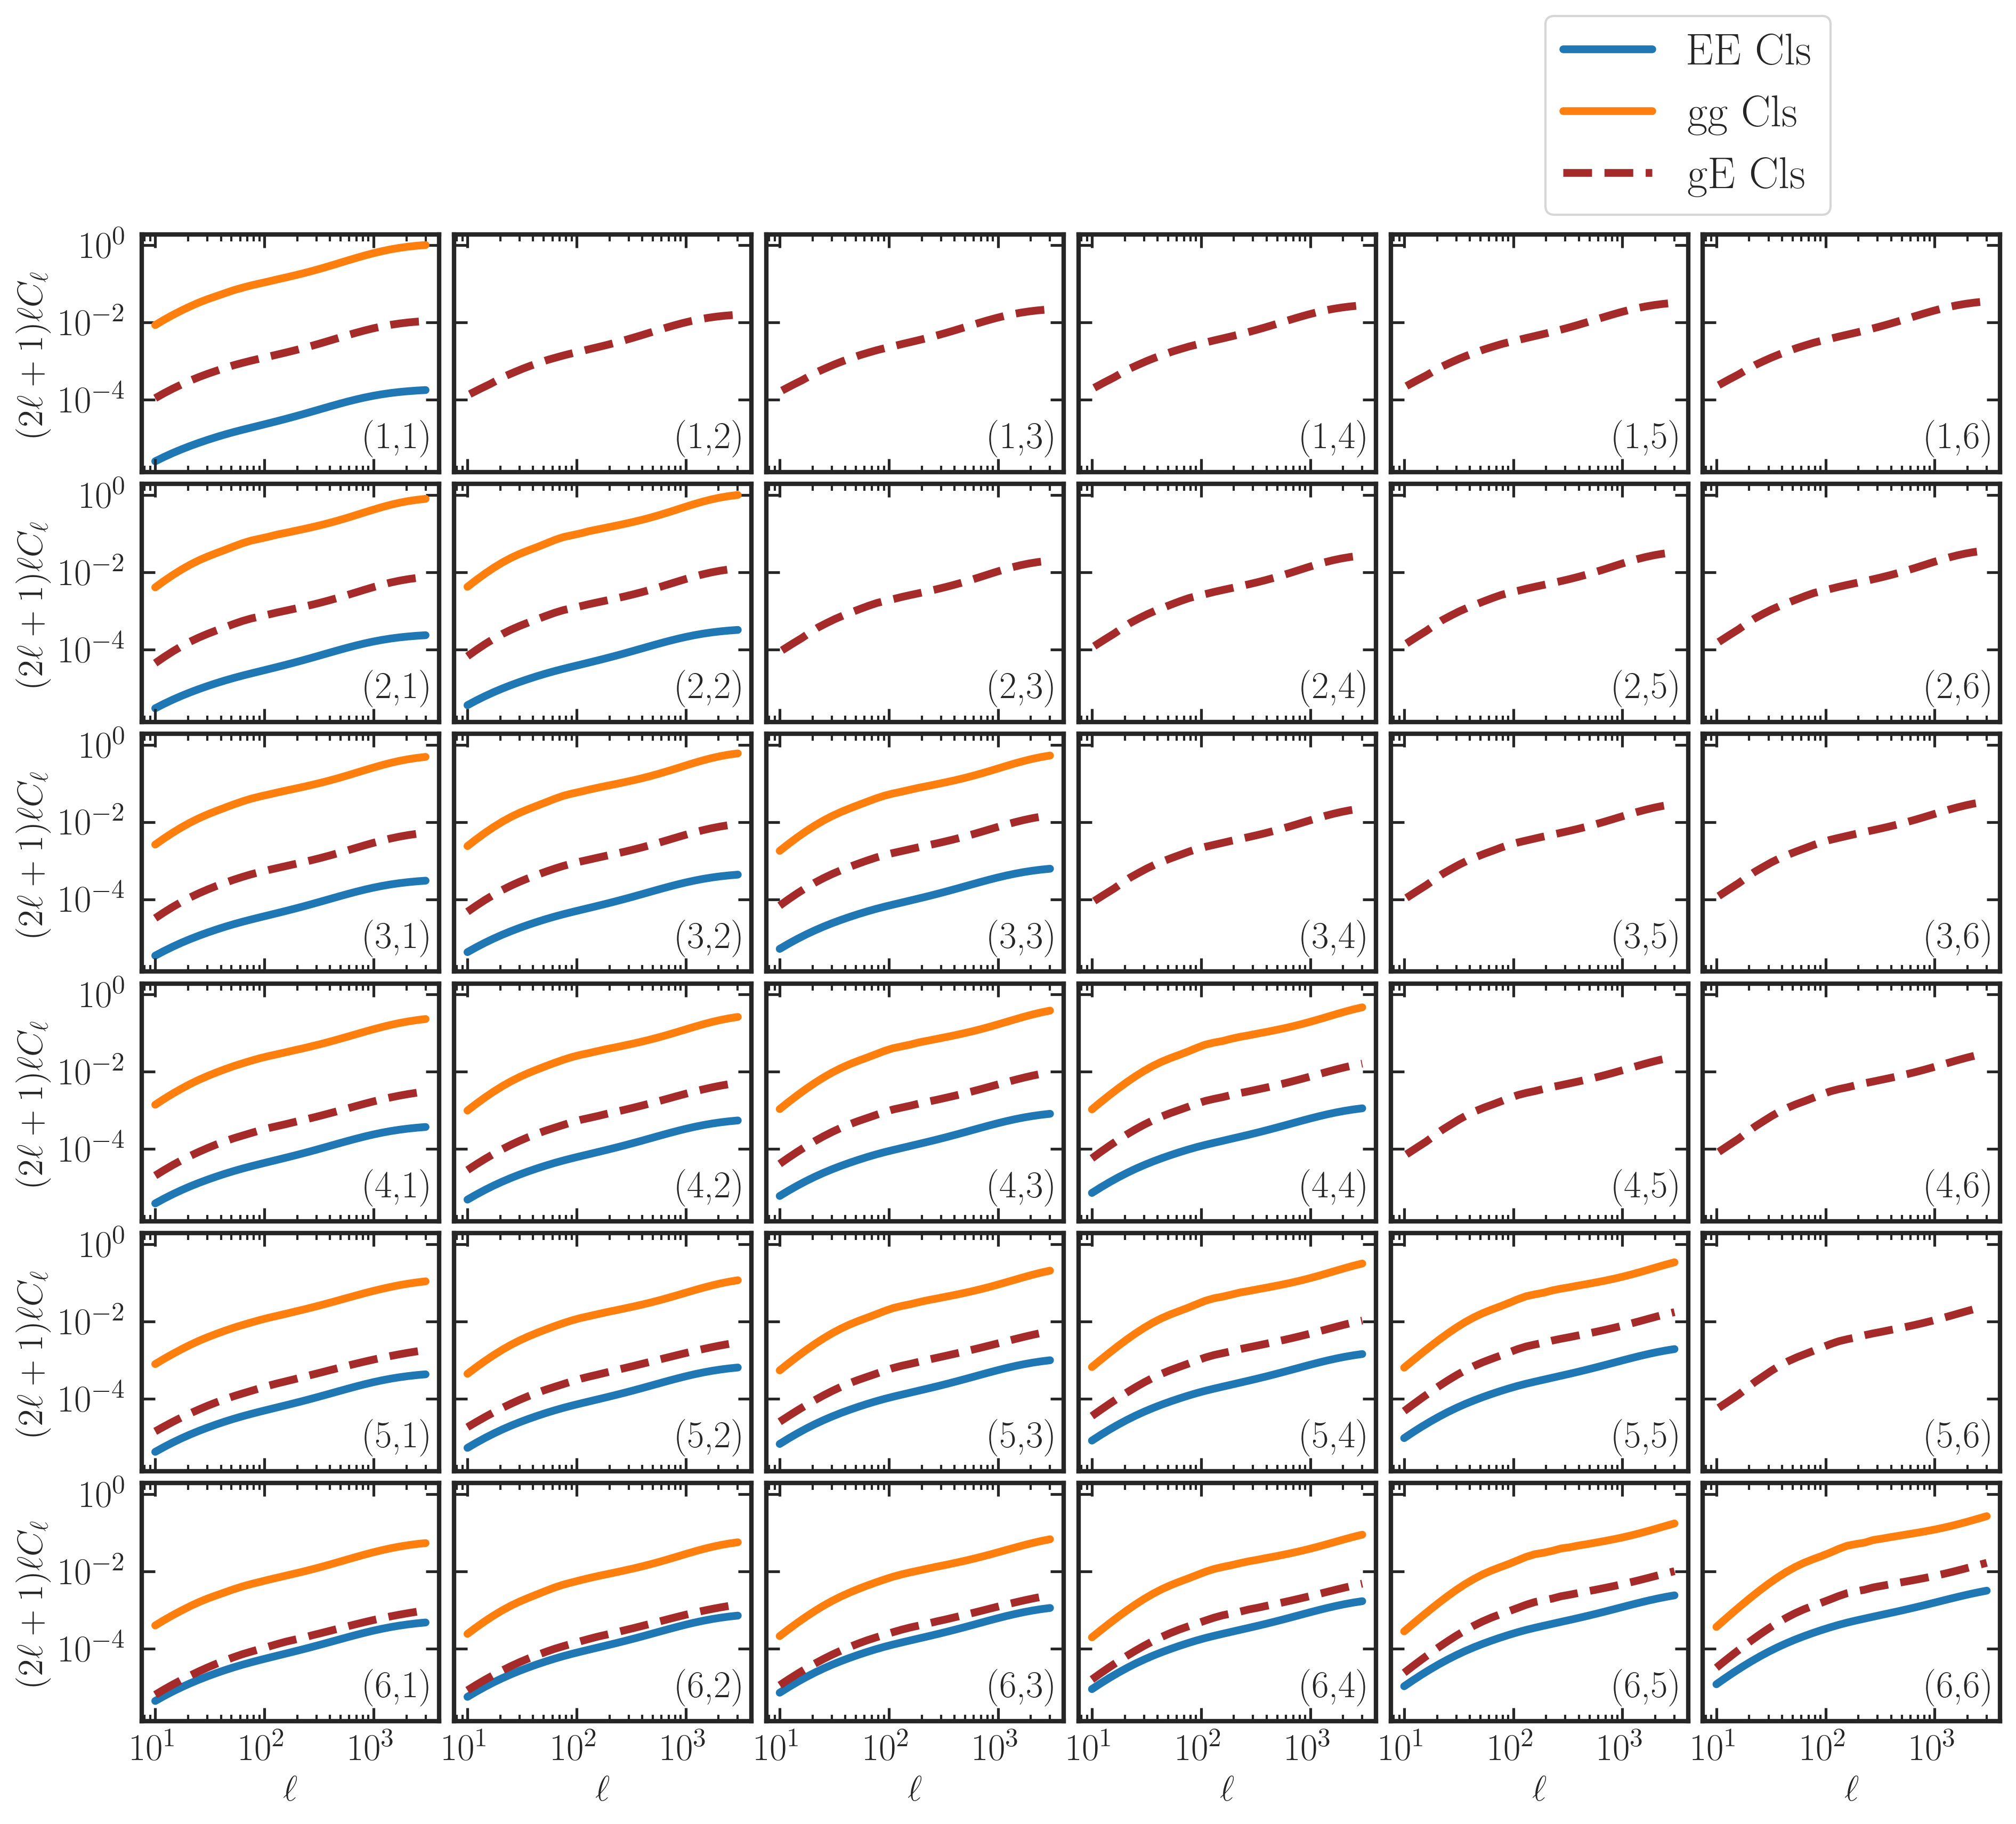

In [66]:
label = 'Cls'
# Choose to plot decoupled/coupled Cls
coupled = False 
if coupled:
    cells_plot = globals()[f'pseudo_cells']; label = 'pseudo-Cls'

fig, axs = plt.subplots(6, 6, figsize=(15,12), sharey=True, sharex=True)
plt.subplots_adjust(wspace=0.05, hspace=0.05)

lw = 3.5
for i in range(6):
    for j in range(6):
        if i>=j:
            axs[i, j].loglog(ells, (2*ells+1)*ells*cells[('SHE', 'SHE',j+1 , i+1)][0,0], lw=lw, ls='-', color='tab:blue', label=r'EE ' + label, zorder=0)
            axs[i, j].loglog(ells, (2*ells+1)*ells*cells[('POS', 'POS',j+1 , i+1)][:] , lw=lw, ls='-', color='tab:orange', label=r'gg ' + label, zorder=1)
            axs[i, j].loglog(ells, (2*ells+1)*ells*cells[('POS', 'SHE',i+1 , j+1)][0], lw=lw, ls='--', color='brown', label=r'gE ' + label, zorder=2)

        else:
            axs[i, j].loglog(ells_mm, (2*ells+1)*ells*cells[('POS', 'SHE',i+1 , j+1)][0] , lw=lw, ls='--', color='brown', label=r'gE' + label, zorder=2)
        
        
        # Plot settings
        axs[i,0].set_ylabel(r'$(2\ell+1)\ell C_{\ell}$', fontsize=16)
        axs[-1,j].set_xlabel(r'$\ell$', fontsize=16)
        axs[i,j].text(0.75, 0.1, f'({i+1},{j+1})', transform=axs[i,j].transAxes, fontsize=17)


axs[0,0].legend(loc='center', bbox_to_anchor=(5.2, 1.5), fontsize=20)


plt.show()       

### 2.4. Save C'ells into fits files 

In [67]:
# Save spectra and shifts into fits files
heracles.write(path_out + 'cells.fits', cells, clobber=True)
heracles.write(path_out + 'pseudo_cells.fits', pseudo_cells, clobber=True)

## 3. Real space correlation functions

In [68]:
#Define theta bins
n_bins = 20
th_min, th_max = 1.0, 400.0  # arcmin
theta_edges = np.logspace(np.log10(th_min), np.log10(th_max), n_bins + 1)
theta_centers = np.sqrt(theta_edges[:-1] * theta_edges[1:])
theta_rad = np.radians(theta_centers/60)

ells_integration = np.arange(2, 60000)  # Multipole moments over which to integrate
ells_integration_wl = np.arange(2, 30000)

In [69]:
correlation_function_EE = AngularCorrelationFunctionWigner(twopoint_sheshe, ells_integration_wl, perturbations.k)
xi_sheshe_plus, xi_sheshe_minus = correlation_function_EE.get_xi(theta_rad)

correlation_function_EG = AngularCorrelationFunctionWigner(twopoint_posshe, ells_integration, perturbations.k)
xi_posshe = correlation_function_EG.get_xi(theta_rad)[0]

correlation_function_GG = AngularCorrelationFunctionWigner(twopoint_pospos, ells_integration, perturbations.k)
xi_pospos = correlation_function_GG.get_xi(theta_rad)

ValueError: too many values to unpack (expected 2)

### 3.1. Plot correlation functions

### 3.2 Save correlation functions into fits files

In [59]:
def write_fits(probe,shift_diff,xi_sheshe_plus,xi_sheshe_minus,xi_posshe,xi_pospos):
    hdr = fits.Header()
    hdr['THMIN'] = 1.0
    hdr['THMAX'] = 400.0
    #hdr['OATH'] = 'UNDEFINED'
    hdr['THUNIT'] = 'arcmin'
    hdr['BINSCALE'] = 'LOG'
    hdr['COORDSYS'] = 'SPHERICAL'
   
    #hdr['SHE_SEL'] = 'UNDEFINED'
    hdr['SOFTNAME'] = 'CLOELIB'
    #hdr['SOFTVER'] = 'UNDEFINED'
    
    primary_hdu = fits.PrimaryHDU(header=hdr)

    hdus = [primary_hdu]

    if probe == 'CS' :
        
        for j in range(6):
            for k in range(j, 6):
                    
                if shift_diff == False:
                    xi_p = xi_sheshe_plus[:, j, k]
                    xi_m = xi_sheshe_minus[:, j, k]
                    file_name = 'EUC_LE3_2PCF-WL-CS-XI-'
                        
                else: 
                        
                    xi_p = xi_sheshe_plus[:, j, k] - xi_sheshe_plus_ref[:, j, k]
                    xi_m = xi_sheshe_minus[:, j, k] - xi_sheshe_minus_ref[:, j, k]
                    file_name = 'EUC_LE3_2PCF-WL-CS-shift-'
                        

       
                xi_x = np.zeros_like(theta_centers)
                weight = np.ones_like(theta_centers)
                sqrt_d = np.zeros_like(theta_centers)
                sqrt_dcor = np.zeros_like(theta_centers)
                npair = np.zeros_like(theta_centers)

       
                cols = [
                    fits.Column(name='THETA', format='D', array=theta_centers),
                    fits.Column(name='XI_P', format='D', array=xi_p),
                    fits.Column(name='XI_M', format='D', array=xi_m),
                    fits.Column(name='XI_X', format='D', array=xi_x),
                    fits.Column(name='WEIGHT', format='D', array=weight),
                    fits.Column(name='SQRT_D', format='D', array=sqrt_d),
                    fits.Column(name='SQRT_DCOR', format='D', array=sqrt_dcor),
                    fits.Column(name='NPAIR', format='K', array=npair)
                    ]

                tbhdu = fits.BinTableHDU.from_columns(cols)
                tbhdu.header['BIN_ID1'] = j + 1
                tbhdu.header['BIN_ID2'] = k + 1
                tbhdu.header['EXTNAME'] = f'SHEARSHEAR2D_{j+1}_{k+1}'

                hdus.append(tbhdu)
   


        hdul = fits.HDUList(hdus)
            

            
            
        
    elif probe == 'GGL' :
        
       
        
       
        
        for j in range(6): #lens
            for k in range(6): #source
                if shift_diff == False:
                    gamma_t = xi_posshe[:,j,k]
                    file_name = 'EUC_LE3_2PCF-WL-GGL-XI-'
                else:
                    gamma_t = xi_posshe[:,j,k] - xi_posshe_ref[:,j,k]
                    file_name = 'EUC_LE3_2PCF-WL-GGL-shift-'
        
       
                gamma_x = np.zeros_like(theta_centers)
                weight = np.ones_like(theta_centers)
                sqrt_d = np.zeros_like(theta_centers)
                sqrt_dcor = np.zeros_like(theta_centers)
                npair = np.zeros_like(theta_centers)

       
                cols = [
                    fits.Column(name='THETA', format='D', array=theta_centers),
                    fits.Column(name='GAMMA_T', format='D', array=gamma_t),
                    fits.Column(name='GAMMA_X', format='D', array=gamma_x),
                    fits.Column(name='WEIGHT', format='D', array=weight),
                    fits.Column(name='SQRT_D', format='D', array=sqrt_d),
                    fits.Column(name='SQRT_DCOR', format='D', array=sqrt_dcor),
                    fits.Column(name='NPAIR', format='K', array=npair)
                    ]

                tbhdu = fits.BinTableHDU.from_columns(cols)
                tbhdu.header['BIN_ID1'] = j + 1
                tbhdu.header['BIN_ID2'] = k + 1
                tbhdu.header['EXTNAME'] = f'POSSHEAR2D_{j+1}_{k+1}'

                hdus.append(tbhdu)
        hdul = fits.HDUList(hdus)
            
        
    elif probe == 'SA' :
        
        
        
        for j in range(6): 
            for k in range(j, 6): 
                if shift_diff == False :
                    w_theta = xi_pospos[:,j,k]
                    file_name = 'EUC_LE3_2PCF-WL-SA-XI-'
                else: 
                    w_theta = xi_pospos[:,j,k] - xi_pospos_ref[:,j,k]
                    file_name = 'EUC_LE3_2PCF-WL-SA-shift-'
        
       
        
                weight = np.ones_like(theta_centers)
                sqrt_d = np.zeros_like(theta_centers)
       

       
                cols = [
                    fits.Column(name='THETA', format='D', array=theta_centers),
                    fits.Column(name='WTHETA', format='D', array=w_theta),
                    fits.Column(name='WEIGHT', format='D', array=weight),
                    fits.Column(name='SQRT_D', format='D', array=sqrt_d),

                    ]

                tbhdu = fits.BinTableHDU.from_columns(cols)
                tbhdu.header['BIN_ID1'] = j + 1
                tbhdu.header['BIN_ID2'] = k + 1
                tbhdu.header['EXTNAME'] = f'POSPOS2D_{j+1}_{k+1}'

                hdus.append(tbhdu)
        
        hdul = fits.HDUList(hdus)       
            
      
            
            
        
    return hdul,file_name

In [70]:
hdul,file_name = write_fits('CS',False,xi_sheshe_plus, xi_sheshe_minus, xi_posshe, xi_pospos)
hdul.writeto(path_out+file_name+'ref'+'.fits',overwrite=True)

hdul,file_name = write_fits('GGL',False,xi_sheshe_plus, xi_sheshe_minus, xi_posshe, xi_pospos)
hdul.writeto(path_out+file_name+'ref'+'.fits',overwrite=True)

hdul,file_name = write_fits('SA',False,xi_sheshe_plus, xi_sheshe_minus, xi_posshe, xi_pospos)
hdul.writeto(path_out+file_name+'ref'+'.fits',overwrite=True)

NameError: name 'xi_sheshe_plus' is not defined

## 4. COSEBI

In [53]:
#Define theta bins
nmax = 10 # first 10 cosebis
th_min, th_max = 1.0, 400.0  # arcmin
ells_integration = np.arange(2, 60000)  # Multipole moments over which to integrate
theta_integration = np.geomspace(th_min, th_max, int(1e5)) * np.pi / 10800

In [54]:
N_thread = 100
# get wn(ell) transfer functions
well = get_W_ell(theta_integration, nmax+1, ells_integration, N_thread)

start calculating roots and norms:
done
start performing the bessel integrals
1 / 11
2 / 11
3 / 11
4 / 11
5 / 11
6 / 11
7 / 11
8 / 11
9 / 11
10 / 11


In [55]:
cosebi_EE = twopoint_sheshe.get_cosebis(ells_integration,nl, ks, well,np.arange(1,nmax))

### 4.1 Plot COSEBI

Text(0, 0.5, '$W_n(\\ell)$')

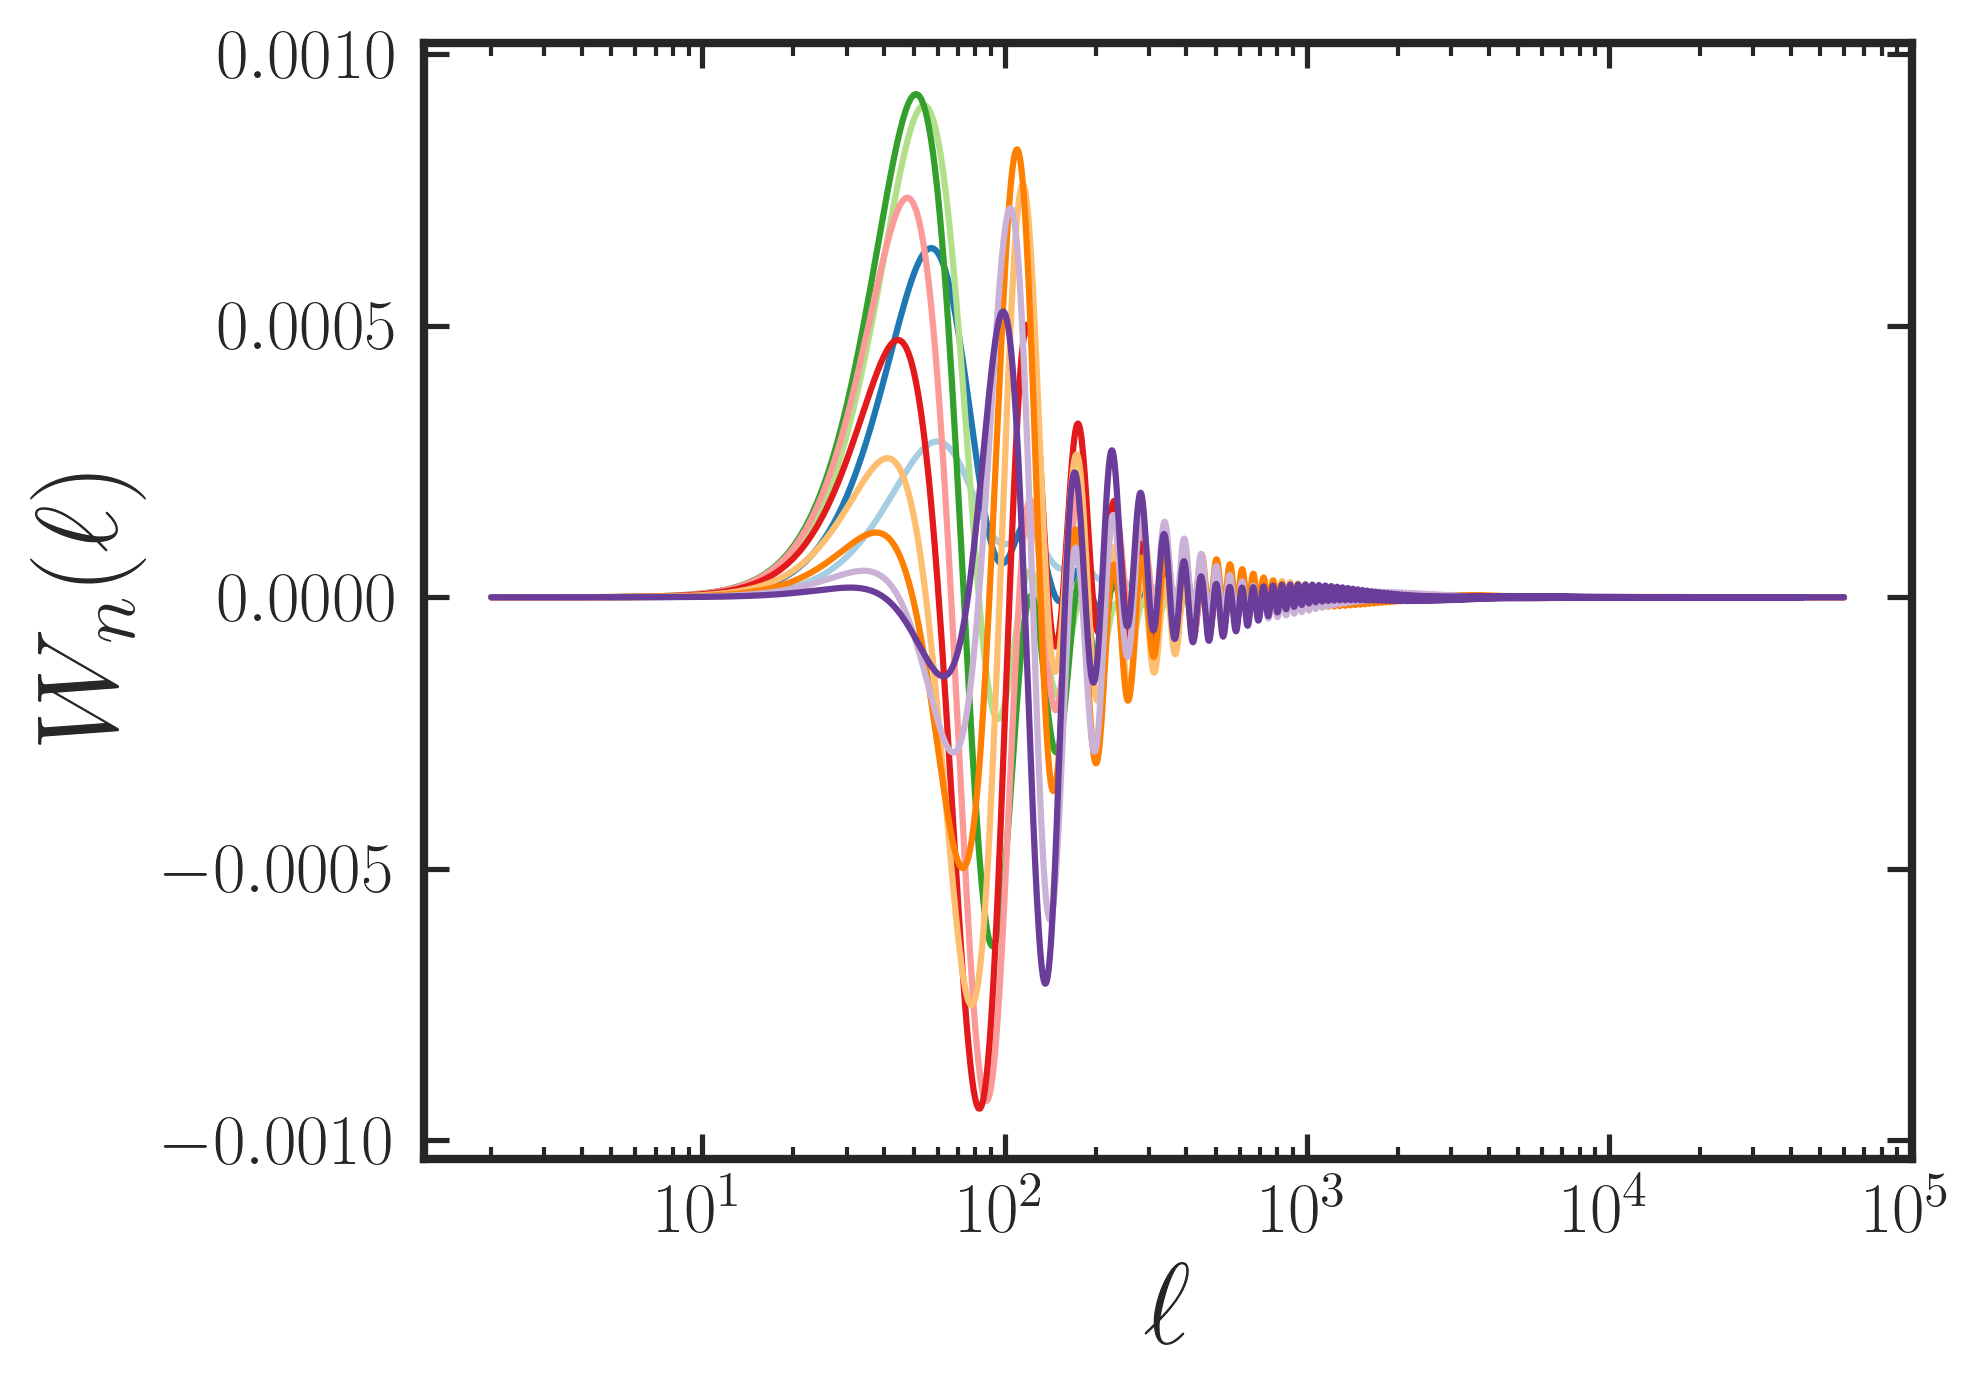

In [56]:
for n in range(1, nmax+1):
    plt.semilogx(ells_integration, well[n])
plt.xlabel('$\ell$')
plt.ylabel('$W_n(\ell)$')

### 4.2. Save COSEBI into fits files

In [57]:
modes = np.arange(1,nmax+1)
def write_fits_cosebi(cosebi_EE_arr):
    
    
    hdr = fits.Header()
    hdr['NMODES'] = len(modes)  #20 for RR2 data
    hdr['SOFTNAME'] = 'CLOELIB'
    primary_hdu = fits.PrimaryHDU(header=hdr)
    hdus = [primary_hdu]     
        
    nbins = 6    
    for j in range(1,nbins+1):
        for k in range(j, nbins+1):
            cosebi_EE = cosebi_EE_arr[(j,k)]
            file_name = 'EUC_LE3_2PCF-WL-CS-COSEBI-'
                        
                    
            cosebi_BB = np.zeros_like(modes)
            cosebi_EB = np.zeros_like(modes)

            cols = [
                fits.Column(name='MODE', format='K', array=modes),
                fits.Column(name='EE', format='D', array=cosebi_EE),
                fits.Column(name='BB', format='D', array=cosebi_BB),
                fits.Column(name='EB', format='D', array=cosebi_EB)
                ]

            tbhdu = fits.BinTableHDU.from_columns(cols)
            tbhdu.header['BIN_ID1'] = j 
            tbhdu.header['BIN_ID2'] = k 
            tbhdu.header['EXTNAME'] = f'SHEARSHEAR2D_COSEBI_{j}_{k}'

            hdus.append(tbhdu)
   


    hdul = fits.HDUList(hdus)
    return hdul,file_name

In [61]:
hdul,file_name = write_fits_cosebi(cosebi_EE)
hdul.writeto(path_out + "cosebi_EE.fits", overwrite=True)